# Notebook 2: Bivariate Relationships

Explores pairwise relationships between quality scores and between scores and heuristic features.
Also shows how quality distributions vary across topics and formats.

In [ ]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')

NB_DIR = Path('.').resolve()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import config

sns.set_theme(style='whitegrid')

FIGURES_DIR = NB_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

def savefig(name):
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()
    plt.close()

TOPIC_NAMES = {
    0: 'Adult', 1: 'Art & Design', 2: 'Soft. Dev.', 3: 'Crime & Law',
    4: 'Edu. & Jobs', 5: 'Hardware', 6: 'Entertainment', 7: 'Social Life',
    8: 'Fashion', 9: 'Finance', 10: 'Food & Dining',
    11: 'Games', 12: 'Health', 13: 'History', 14: 'Home & Hobbies',
    15: 'Industrial', 16: 'Literature', 17: 'Politics', 18: 'Religion',
    19: 'Sci. & Tech.', 20: 'Software', 21: 'Sports',
    22: 'Transport.', 23: 'Travel'
}

FORMAT_NAMES = {
    0: 'Academic', 1: 'Content List', 2: 'Creative', 3: 'Cust. Support',
    4: 'Comments', 5: 'FAQ', 6: 'Truncated', 7: 'Knowledge Art.',
    8: 'Legal', 9: 'Listicle', 10: 'News Art.', 11: 'Nonfiction',
    12: 'About (Org.)', 13: 'News (Org.)', 14: 'About (Pers.)', 15: 'Blog',
    16: 'Product Page', 17: 'Q&A', 18: 'Spam/Ads', 19: 'Struct. Data',
    20: 'Docs', 21: 'Transcript', 22: 'Tutorial', 23: 'User Review'
}

# load data
df = pd.read_parquet(config.MASTER_PARQUET)
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')

# all potential score columns!!
ALL_SCORE_COLS = [
    'dclm_score', 'fwedu_rounded',
    'pc_arc_easy', 'pc_piqa', 'pc_sciq', 'pc_lambada_es',
    'qr_writing_style', 'qr_required_expertise', 'qr_facts_and_trivia', 'qr_educational_value'
]
ALL_SCORE_COLS = [c for c in ALL_SCORE_COLS if c in df.columns]

SCORE_DISPLAY = {
    'dclm_score': 'DCLM',
    'fwedu_rounded': 'FWEdu',
    'pc_arc_easy': 'PC-ARC',
    'pc_piqa': 'PC-PIQA',
    'pc_sciq': 'PC-SciQ',
    'pc_lambada_es': 'PC-LAMBADA',
    'qr_writing_style': 'QR-Writing',
    'qr_required_expertise': 'QR-Expertise',
    'qr_facts_and_trivia': 'QR-Facts',
    'qr_educational_value': 'QR-EduVal',
}

# filter to scores with >= 10% coverage for correlation analysis
coverage = df[ALL_SCORE_COLS].notna().mean()
GOOD_SCORES = [c for c in ALL_SCORE_COLS if coverage[c] >= 0.10]
print(f'\nScore coverage:')
for c in ALL_SCORE_COLS:
    flag = '' if coverage[c] >= 0.10 else ' [<10% coverage, excluded from correlation]'
    print(f'  {c}: {coverage[c]*100:.1f}%{flag}')
print(f'\nUsing {len(GOOD_SCORES)} scores for correlation analysis: {GOOD_SCORES}')

Loaded 2,263,456 rows, 56 columns

Score coverage:
  dclm_score: 100.0%
  fwedu_rounded: 100.0%
  pc_arc_easy: 100.0%
  pc_piqa: 100.0%
  pc_sciq: 100.0%
  pc_lambada_es: 100.0%
  qr_writing_style: 43.1%
  qr_required_expertise: 43.1%
  qr_facts_and_trivia: 43.1%
  qr_educational_value: 43.1%

Using 10 scores for correlation analysis: ['dclm_score', 'fwedu_rounded', 'pc_arc_easy', 'pc_piqa', 'pc_sciq', 'pc_lambada_es', 'qr_writing_style', 'qr_required_expertise', 'qr_facts_and_trivia', 'qr_educational_value']


Computing correlations on 974,877 complete rows (all good scores non-NaN)


Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\02_score_correlations.png


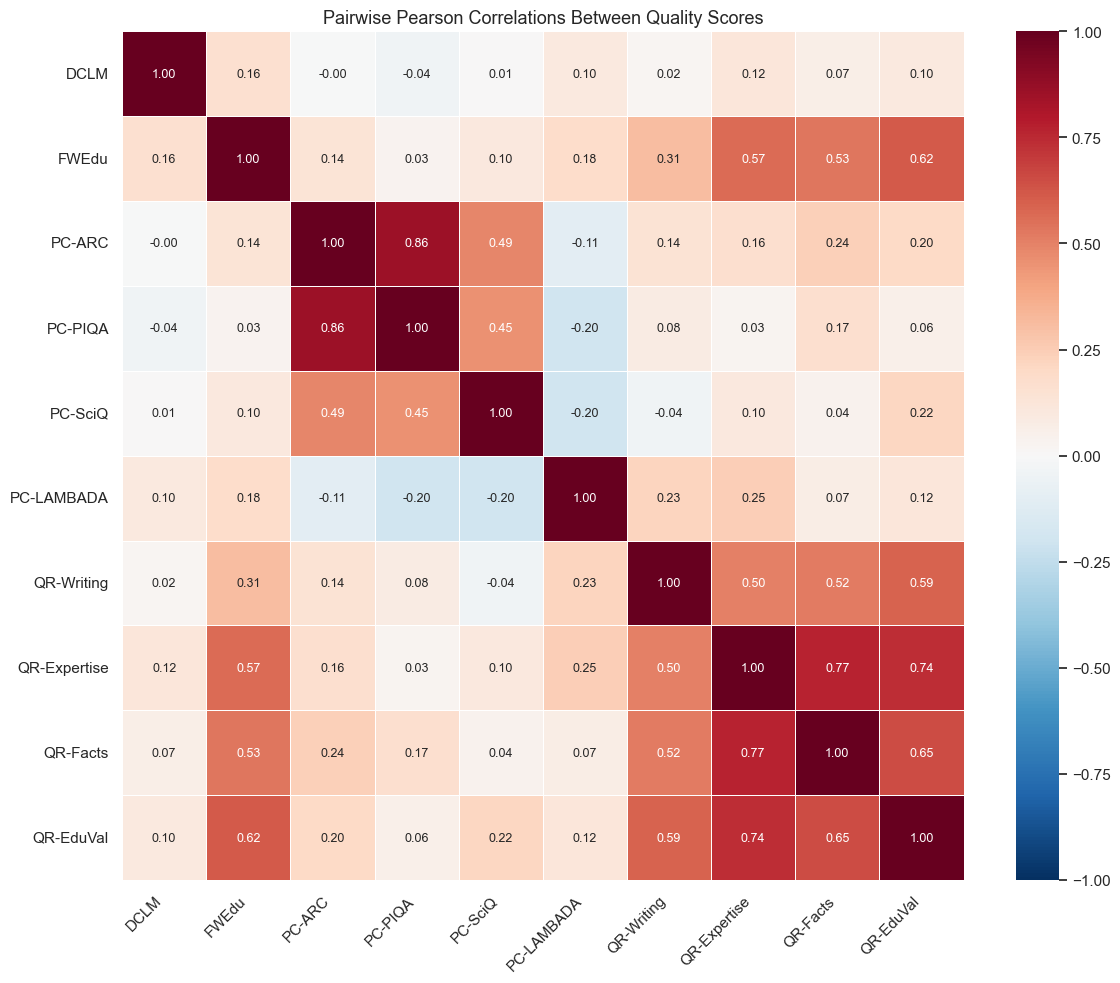

In [2]:
# --- Cell 2: Pairwise score correlation heatmap ---

score_df = df[GOOD_SCORES].dropna()
print(f'Computing correlations on {len(score_df):,} complete rows (all good scores non-NaN)')

# If too few complete rows (because some scores have low coverage), use pairwise
if len(score_df) < 1000:
    print('Warning: few complete rows. Using pairwise correlations instead.')
    corr_matrix = df[GOOD_SCORES].corr(method='pearson')
else:
    corr_matrix = score_df.corr(method='pearson')

labels = [SCORE_DISPLAY.get(c, c) for c in GOOD_SCORES]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
# No masking — show full matrix for readability
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('Pairwise Pearson Correlations Between Quality Scores', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

savefig('02_score_correlations.png')

Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\02_violin_by_topic.png


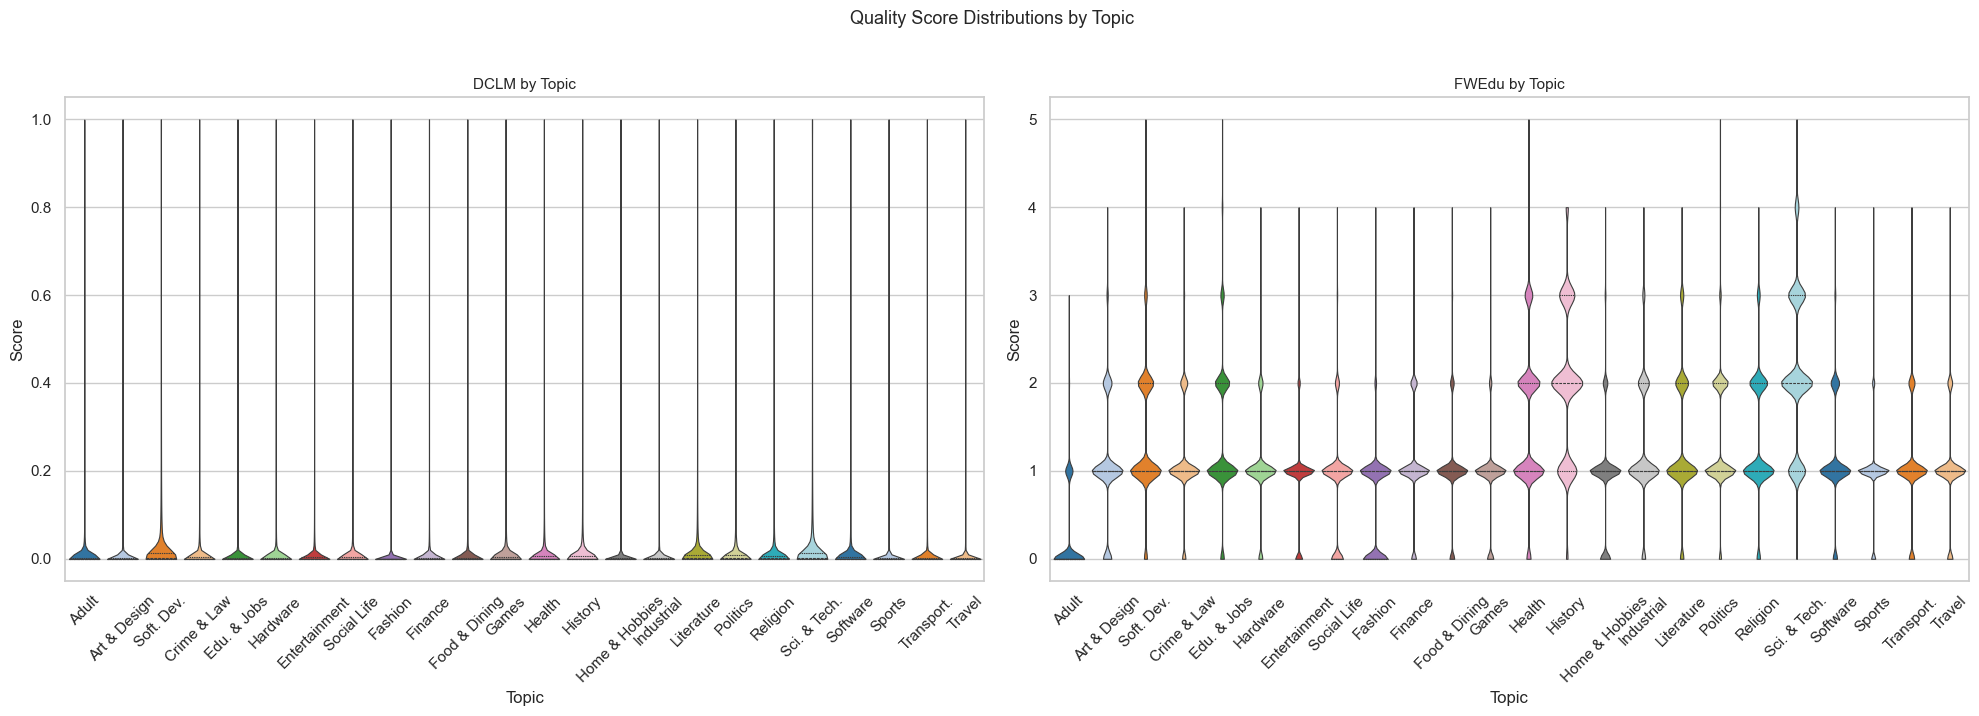

In [3]:
# --- Cell 3: Violin plots by topic ---

# Pick the two most-covered scores for violin plots
violin_scores = ['dclm_score', 'fwedu_rounded']
violin_scores = [c for c in violin_scores if c in df.columns]

topic_order = sorted(df['topic'].dropna().unique().astype(int))
topic_labels = [TOPIC_NAMES.get(t, str(t)) for t in topic_order]

fig, axes = plt.subplots(1, len(violin_scores), figsize=(20, 7))
if len(violin_scores) == 1:
    axes = [axes]

palette = sns.color_palette('tab20', n_colors=len(topic_order))

for ax, score in zip(axes, violin_scores):
    sub = df[['topic', score]].dropna()
    sub['topic_name'] = sub['topic'].astype(int).map(TOPIC_NAMES)
    # Order by topic id
    ordered_labels = [TOPIC_NAMES[t] for t in topic_order if t in sub['topic'].astype(int).unique()]
    sns.violinplot(
        data=sub,
        x='topic_name',
        y=score,
        order=ordered_labels,
        palette=palette,
        ax=ax,
        inner='quartile',
        cut=0,
        linewidth=0.8
    )
    ax.set_title(f'{SCORE_DISPLAY.get(score, score)} by Topic', fontsize=11)
    ax.set_xlabel('Topic')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Quality Score Distributions by Topic', fontsize=13, y=1.02)
savefig('02_violin_by_topic.png')

Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\02_violin_by_format.png


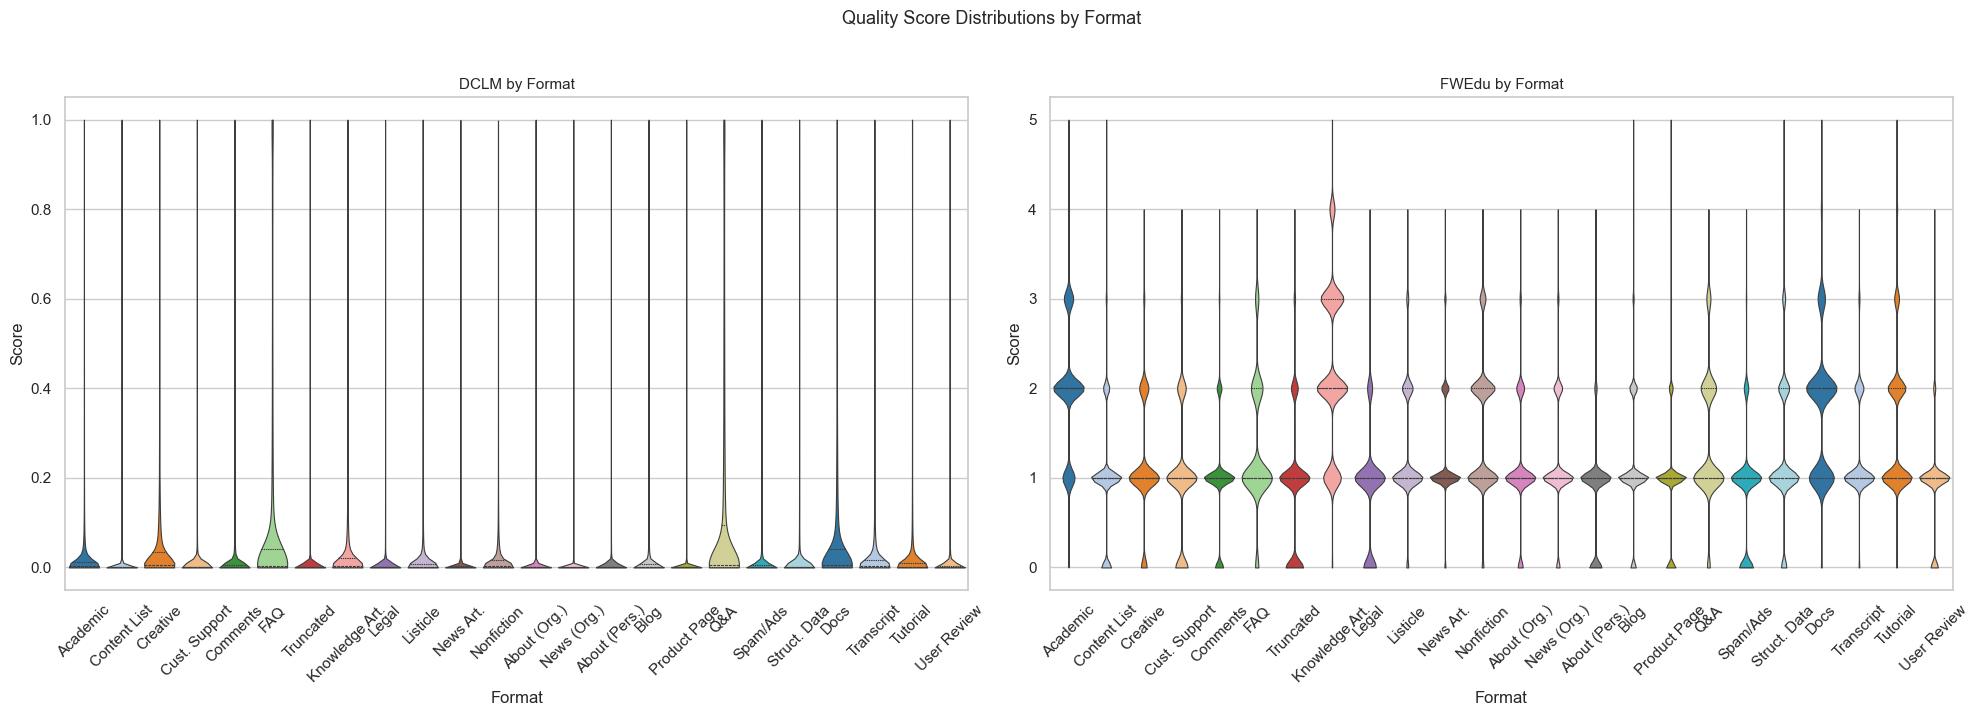

In [4]:
# --- Cell 4: Violin plots by format ---

format_order = sorted(df['format'].dropna().unique().astype(int))

fig, axes = plt.subplots(1, len(violin_scores), figsize=(20, 7))
if len(violin_scores) == 1:
    axes = [axes]

palette_fmt = sns.color_palette('tab20', n_colors=len(format_order))

for ax, score in zip(axes, violin_scores):
    sub = df[['format', score]].dropna()
    sub['format_name'] = sub['format'].astype(int).map(FORMAT_NAMES)
    ordered_fmt_labels = [FORMAT_NAMES[f] for f in format_order if f in sub['format'].astype(int).unique()]
    sns.violinplot(
        data=sub,
        x='format_name',
        y=score,
        order=ordered_fmt_labels,
        palette=palette_fmt,
        ax=ax,
        inner='quartile',
        cut=0,
        linewidth=0.8
    )
    ax.set_title(f'{SCORE_DISPLAY.get(score, score)} by Format', fontsize=11)
    ax.set_xlabel('Format')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Quality Score Distributions by Format', fontsize=13, y=1.02)
savefig('02_violin_by_format.png')

Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\02_score_vs_heuristics.png


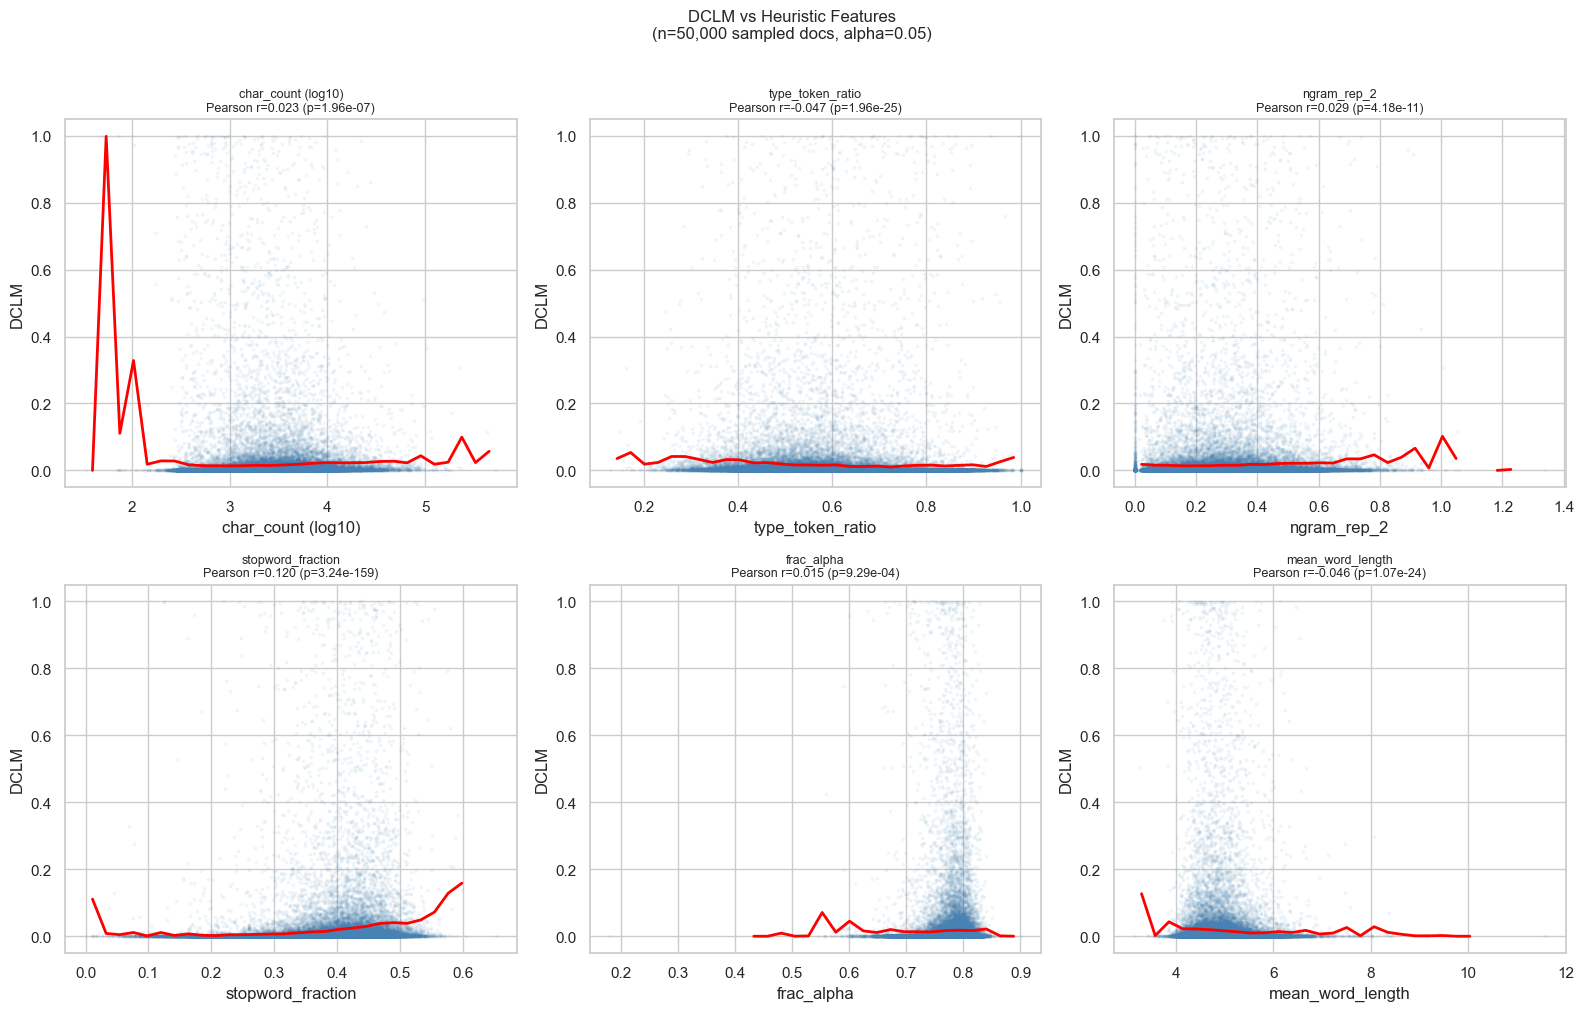

In [5]:
# --- Cell 5: Score vs heuristic scatterplots ---

# Use dclm_score as the primary score for scatter
primary_score = 'dclm_score'
HEURISTIC_SCATTER = [
    ('char_count', 'char_count (log10)'),
    ('type_token_ratio', 'type_token_ratio'),
    ('ngram_rep_2', 'ngram_rep_2'),
    ('stopword_fraction', 'stopword_fraction'),
    ('frac_alpha', 'frac_alpha'),
    ('mean_word_length', 'mean_word_length'),
]
HEURISTIC_SCATTER = [(c, lbl) for c, lbl in HEURISTIC_SCATTER if c in df.columns]

# Sample for speed
N_SAMPLE = min(50_000, len(df))
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=N_SAMPLE, replace=False)
sample = df.iloc[idx].copy()

n_cols_grid = 3
n_rows_grid = int(np.ceil(len(HEURISTIC_SCATTER) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(16, 5 * n_rows_grid))
axes = axes.flatten()

for i, (col, label) in enumerate(HEURISTIC_SCATTER):
    ax = axes[i]
    sub = sample[[col, primary_score]].dropna()
    x_vals = sub[col]
    # Log-transform character count
    if col == 'char_count':
        x_vals = np.log10(x_vals.clip(lower=1))
    ax.scatter(x_vals, sub[primary_score], alpha=0.05, s=3, color='steelblue', rasterized=True)
    # Add a trend line using a smoothed mean
    try:
        from scipy.stats import binned_statistic
        bin_means, bin_edges, _ = binned_statistic(x_vals, sub[primary_score], statistic='mean', bins=30)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.plot(bin_centers, bin_means, color='red', lw=2, label='binned mean')
    except Exception:
        pass
    ax.set_xlabel(label)
    ax.set_ylabel(SCORE_DISPLAY.get(primary_score, primary_score))
    # Compute Pearson r
    try:
        r, p = pearsonr(x_vals, sub[primary_score])
        ax.set_title(f'{label}\nPearson r={r:.3f} (p={p:.2e})', fontsize=9)
    except Exception:
        ax.set_title(label, fontsize=9)

for j in range(len(HEURISTIC_SCATTER), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'{SCORE_DISPLAY.get(primary_score, primary_score)} vs Heuristic Features\n(n={N_SAMPLE:,} sampled docs, alpha=0.05)',
             fontsize=12, y=1.01)
savefig('02_score_vs_heuristics.png')

Computing fwedu_rounded_pct_topic on the fly...


Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\02_raw_vs_percentile.png


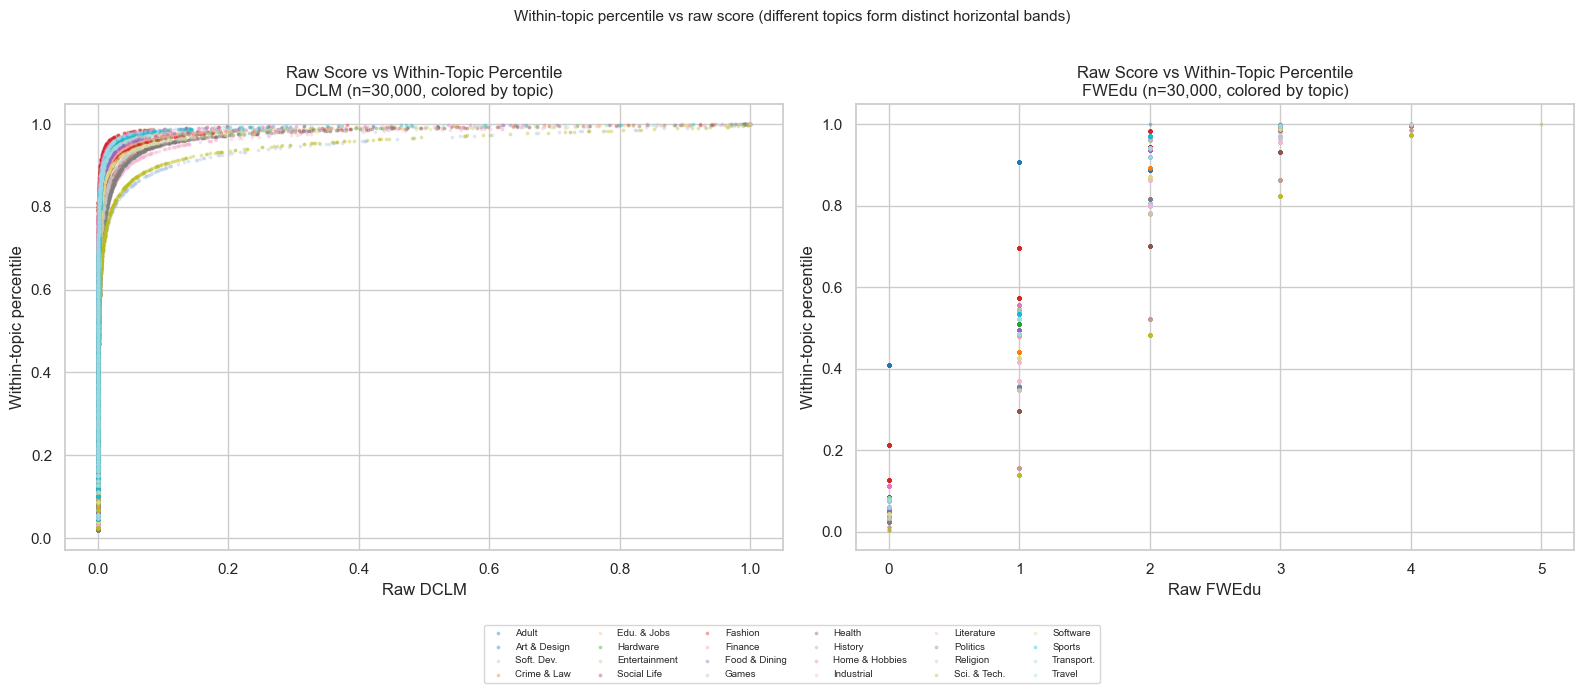

In [6]:
# --- Cell 6: Raw score vs within-topic percentile ---

# Check if percentile columns already exist, else compute on the fly
pct_scores = ['dclm_score', 'fwedu_rounded']
pct_scores = [c for c in pct_scores if c in df.columns]

N_SAMPLE_PCT = min(30_000, len(df))
rng2 = np.random.default_rng(123)
idx2 = rng2.choice(len(df), size=N_SAMPLE_PCT, replace=False)
sample2 = df.iloc[idx2].copy()

fig, axes = plt.subplots(1, len(pct_scores), figsize=(16, 6))
if len(pct_scores) == 1:
    axes = [axes]

n_topics = df['topic'].nunique()
cmap = cm.get_cmap('tab20', n_topics)

for ax, score in zip(axes, pct_scores):
    pct_col = f'{score}_pct_topic'

    # Compute percentile if column missing
    if pct_col not in sample2.columns:
        print(f'Computing {pct_col} on the fly...')
        sample2[pct_col] = (
            sample2.groupby('topic')[score]
            .rank(method='average', pct=True, na_option='keep')
        )

    sub = sample2[['topic', score, pct_col]].dropna()

    unique_topics = sorted(sub['topic'].unique().astype(int))
    for t_idx, t in enumerate(unique_topics):
        mask = sub['topic'].astype(int) == t
        ax.scatter(
            sub.loc[mask, score],
            sub.loc[mask, pct_col],
            s=3, alpha=0.3,
            color=cmap(t_idx),
            label=TOPIC_NAMES.get(t, str(t)),
            rasterized=True
        )

    ax.set_xlabel(f'Raw {SCORE_DISPLAY.get(score, score)}')
    ax.set_ylabel('Within-topic percentile')
    ax.set_title(
        f'Raw Score vs Within-Topic Percentile\n{SCORE_DISPLAY.get(score, score)} '
        f'(n={len(sub):,}, colored by topic)'
    )

# One legend for the whole figure, placed outside
handles, labels_leg = axes[-1].get_legend_handles_labels()
# Deduplicate
by_label = dict(zip(labels_leg, handles))
fig.legend(
    by_label.values(), by_label.keys(),
    loc='lower center', ncol=6, fontsize=7,
    bbox_to_anchor=(0.5, -0.12), frameon=True
)

fig.suptitle(
    'Within-topic percentile vs raw score (different topics form distinct horizontal bands)',
    fontsize=11, y=1.01
)
savefig('02_raw_vs_percentile.png')